In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

Rows:  191033
Columns:  85
['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Va

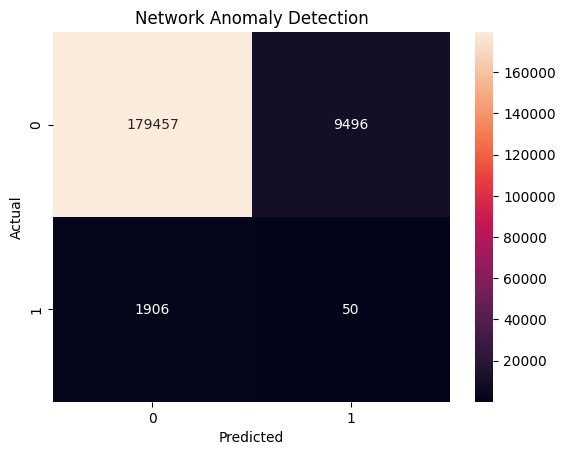

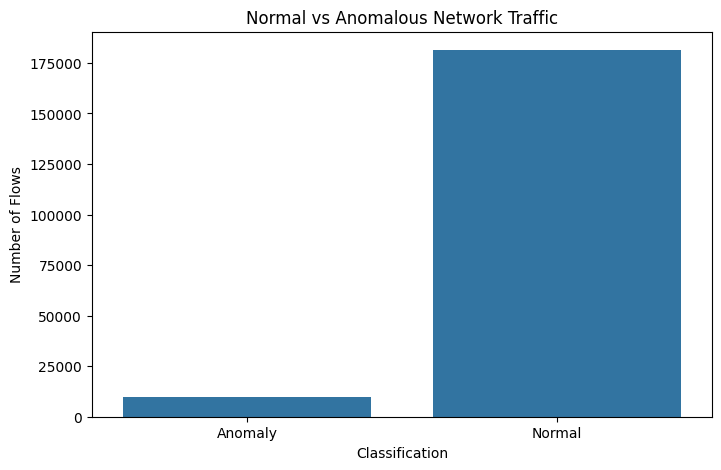

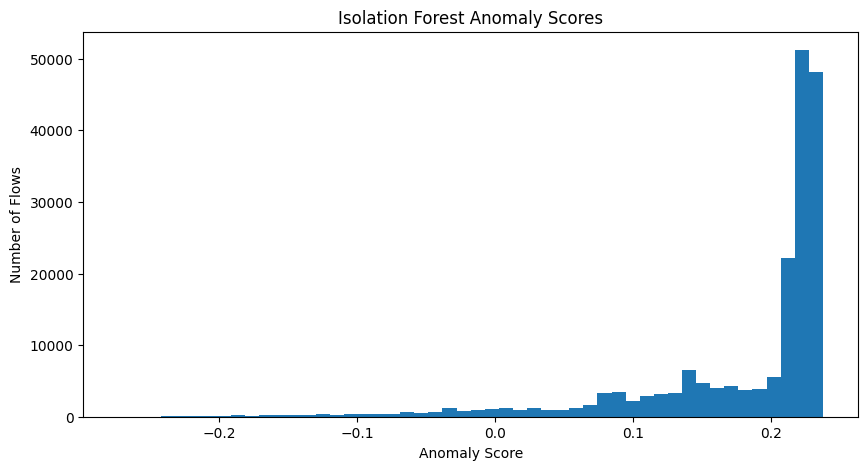

['model/scaler.pkl']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os # Import the os module

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

#Load the dataset
df = pd.read_csv("/content/network_traffic.csv")
#look at the data
df.head()
#check dimensions
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])
#check columns
print(df.columns.tolist())
df.info()

#Understand the data
df[" Label"].value_counts()

#Clean the dataset
#remove duplicate records
df= df.drop_duplicates()
#replace infinity
df = df.replace([np.inf , -np.inf], np.nan)
#checking missing values
print(df.isnull().sum())
#drop missing values
df = df.dropna()
#check
print(df.shape)

#Seprate labels from features
labels = df[" Label"].copy()
x_processed_features = df.drop(columns=[" Label"]) # Renamed for clarity

#Remove unsuitable columns
columns_to_remove = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]
for col in columns_to_remove:
  if col in x_processed_features.columns:
    x_processed_features = x_processed_features.drop(columns=[col])

x_processed_features = pd.get_dummies(x_processed_features)

#Make sure everything is numeric
print(x_processed_features.dtypes.value_counts())
x_processed_features = x_processed_features.apply(pd.to_numeric, errors="coerce")
x_processed_features = x_processed_features.replace([np.inf, -np.inf], np.nan)
x_processed_features = x_processed_features.dropna()

# The lines below are redundant and overwrite previous processing, so they are removed.
# labels= df[" Label"].copy()
# x = df.drop(columns=[" Label"])

#select your features
features = [
    " Flow Duration", # Corrected with leading space
    " Total Fwd Packets", # Corrected with leading space
    " Total Backward Packets", # Corrected with leading space
    "Total Length of Fwd Packets", # No leading space as per original df.columns
    " Total Length of Bwd Packets", # Corrected with leading space
    "Flow Bytes/s", # CORRECTED: Removed leading space
    " Flow Packets/s", # Corrected with leading space
    " Fwd Packet Length Mean", # Corrected with leading space
    " Bwd Packet Length Mean" # Corrected with leading space
]
X = x_processed_features[features] # Now X is properly defined here

#Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train Isolation Forest
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(X_scaled)

#Understanding contamination
contamination=0.03

#Generate predictions
predictions = model.predict(X_scaled)
result = np.where(predictions == -1, "Anomaly", "Normal")
print(result[:20])

#Calculate anomaly scores
scores = model.decision_function(X_scaled)
results = pd.DataFrame({
    "Actual": labels,
    "Prediction": result,
    "Anomaly_Score": scores
})

#Convert your actual labels
actual = np.where(labels == "BENIGN", "Normal", "Anomaly")

#Evaluate the model
y_true = np.where(labels == "BENIGN", 0, 1)
y_pred = np.where(predictions == 1, 0, 1)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Anomaly"]
    )
)

#Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Network Anomaly Detection")
plt.show()

#Visualize anomalies
plt.figure(figsize=(8, 5))

sns.countplot(x=result)

plt.title("Normal vs Anomalous Network Traffic")
plt.xlabel("Classification")
plt.ylabel("Number of Flows")

plt.show()

#Visualize anomaly scores
plt.figure(figsize=(10, 5))

plt.hist(scores, bins=50)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")
plt.title("Isolation Forest Anomaly Scores")

plt.show()

# Create the 'model' directory if it doesn't exist
os.makedirs("model", exist_ok=True)

#Save the model
joblib.dump(
    model,
    "model/isolation_forest.pkl"
)
joblib.dump(
    scaler,
    "model/scaler.pkl"
)